In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from Analysis import Analysis
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
from sklearn.decomposition import PCA

In [2]:
def PCA_fit(Re_c, Im_c):
    pca = PCA()
    c_data = np.stack([Re_c, Im_c], axis=1)  # shape (N,2)
    pca.fit(c_data)
    return pca

def PCA_apply(pca, Re_c, Im_c):
    c_data = np.stack([Re_c, Im_c], axis=1)
    c_pca = pca.transform(c_data)
    return c_pca[:,0], c_pca[:,1]

In [3]:
fogi_tx = "/2025-08-11/2025-08-11T185836_bfd460ab-e2_fogi_ac_Stark_shift"
dd_tx = datadict_from_hdf5(header + fogi_tx +"/data")
fogi_rx = "/2025-08-12/2025-08-12T081806_7032461e-e2_fogi_ac_Stark_shift"
dd_rx = datadict_from_hdf5(header + fogi_rx +"/data")

x_tx = np.unique(dd_tx['fogi_freq']['values'])
y_tx = np.unique(dd_tx['amplitude']['values'])
z_tx = dd_tx['s11']['values']
pca_model_tx = PCA_fit(z_tx.real, z_tx.imag)
PCA1_tx, PCA2_tx = PCA_apply(pca_model_tx, z_tx.real, z_tx.imag)

x_rx = np.unique(dd_rx['fogi_freq']['values'])
y_rx = np.unique(dd_rx['amplitude']['values'])
z_rx = dd_rx['s11']['values']
pca_model_rx = PCA_fit(z_rx.real, z_rx.imag)
PCA1_rx, PCA2_rx = PCA_apply(pca_model_rx, z_rx.real, z_rx.imag)

In [4]:
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti
name_dict_tx = dict(
    data1 = dict(amp=0.1, date="2025-08-11", acquire_time="233236", 
                 params=dict(fit_start=250, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data2 = dict(amp=0.2, date="2025-08-11", acquire_time="235442", 
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data3 = dict(amp=0.25, date="2025-08-12", acquire_time="000905", 
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[0])), 

    data4 = dict(amp=0.275, date="2025-08-12", acquire_time="111626", 
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False),
                 skip=[6, 12]), 

    data5 = dict(amp=0.3, date="2025-08-12", acquire_time="112459", 
                 params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[7, 8])), 

    data6 = dict(amp=0.325, date="2025-08-12", acquire_time="114011", 
                 params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[11, 12])), 

    data7 = dict(amp=0.34, date="2025-08-12", acquire_time="114630", 
                 params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[10, 11, 12, 13])), 

    data8 = dict(amp=0.35, date="2025-08-12", acquire_time="115252", 
                 params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[10, 11, 12, 13])), 

    data9 = dict(amp=0.36, date="2025-08-12", acquire_time="115914", 
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[16, 17, 18, 19])),

    data10 = dict(amp=0.365, date="2025-08-12", acquire_time="120843", 
                  params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                              skip=[14, 15, 16, 17, 18])), 

    data11 = dict(amp=0.37, date="2025-08-12", acquire_time="121810", 
                  params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                              skip=[16, 17, 18, 19, 20])),)

target_freq = 9.38
readout_lo_freq_tx = 9.5
dataobj_tx = WaveformAnalysisMulti(name_dict_tx, header)
dataobj_tx.generate_results(readout_lo_freq_tx, thesis=True)
amps_tx, res_tx, Gammas_tx, fogi_freqs_tx = dataobj_tx.amp_Gamma(target_freq)

0.1 2025-08-11 233236
0.2 2025-08-11 235442
0.25 2025-08-12 000905
0.275 2025-08-12 111626
0.3 2025-08-12 112459
0.325 2025-08-12 114011
0.34 2025-08-12 114630
0.35 2025-08-12 115252
0.36 2025-08-12 115914
0.365 2025-08-12 120843
0.37 2025-08-12 121810
{'a0': 0.0, 'a2': 0.020291307998881347, 'a4': 8.829936781751258e-11, 'a6': 3.0871483147620893e-10, 'a8': 7.851798922153819e-08, 'a10': 32.36225592470154}


In [5]:
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti
name_dict_rx = dict(
    data1 = dict(amp=0.1, date="2025-08-12", acquire_time="084212",
                 params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[10])), 

    data2 = dict(amp=0.2, date="2025-08-12", acquire_time="090429",
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data3 = dict(amp=0.25, date="2025-08-12", acquire_time="091859",
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data4 = dict(amp=0.3, date="2025-08-12", acquire_time="092652",
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data5 = dict(amp=0.325, date="2025-08-12", acquire_time="094155",
                 params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data6 = dict(amp=0.35, date="2025-08-12", acquire_time="095041",
                 params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 

    data7 = dict(amp=0.375, date="2025-08-12", acquire_time="095701",
                 params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[9])), 

    data8 = dict(amp=0.4, date="2025-08-12", acquire_time="100328",
                 params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[14, 15, 16, 17, 18])), 

    data9 = dict(amp=0.425, date="2025-08-12", acquire_time="101441",
                 params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[9, 20])), 

    data10 = dict(amp=0.45, date="2025-08-12", acquire_time="102604",
                  params=dict(fit_start=50, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False,
                             skip=[13, 14, 15, 16, 17, 18, 19, 20])), 
)

target_freq = 9.38
readout_lo_freq_rx = 9.5
dataobj_rx = WaveformAnalysisMulti(name_dict_rx, header)
dataobj_rx.generate_results(readout_lo_freq_rx, thesis=True)
amps_rx, res_rx, Gammas_rx, fogi_freqs_rx = dataobj_rx.amp_Gamma(target_freq)

0.1 2025-08-12 084212
0.2 2025-08-12 090429
0.25 2025-08-12 091859
0.3 2025-08-12 092652
0.325 2025-08-12 094155
0.35 2025-08-12 095041
0.375 2025-08-12 095701
0.4 2025-08-12 100328
0.425 2025-08-12 101441
0.45 2025-08-12 102604
{'a0': 0.0, 'a2': 0.021829579357296236, 'a4': 6.19678476532215e-07, 'a6': 0.19391881880448203, 'a8': 1.7541523789077473e-14, 'a10': 4.4433497770057784e-08}


<>:58: SyntaxWarning: invalid escape sequence '\G'
<>:106: SyntaxWarning: invalid escape sequence '\G'
<>:58: SyntaxWarning: invalid escape sequence '\G'
<>:106: SyntaxWarning: invalid escape sequence '\G'
C:\Users\qipe\AppData\Local\Temp\ipykernel_30276\1838517363.py:58: SyntaxWarning: invalid escape sequence '\G'
  ax.set_ylabel('$\Gamma_f/2\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_30276\1838517363.py:106: SyntaxWarning: invalid escape sequence '\G'
  ax.set_ylabel('$\Gamma_f/2\pi$ (MHz)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_30276\1838517363.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')
C:\Users\qipe\AppData\Local\Temp\ipykernel_30276\1838517363.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be re

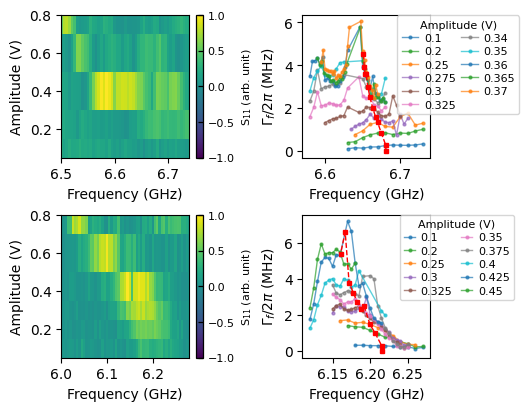

In [6]:
from cycler import cycler

fig, axes = plt.subplots(2, 2, figsize=(5, 4), constrained_layout=True)

# 共通rcParams
plt.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'font.size': 8,
    'axes.linewidth': 0.9,
    'xtick.top': True,
    'xtick.bottom': True,
    'ytick.left': True,
    'ytick.right': True,
    'lines.linewidth': 1,
    'lines.markersize': 2
})
colors = [
    'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 
    'tab:brown', 'tab:pink', 'tab:gray', 'tab:cyan',
    #'tab:olive'#, 'tab:yellow', 'tab:black'
]
# -------------------------------
# 1枚目: colormap
x_min, x_max = 6.5, 6.74
y_min, y_max = 0.05, 0.8

x_idx = (x_tx >= x_min) & (x_tx <= x_max)
y_idx = (y_tx >= y_min) & (y_tx <= y_max)

data = np.abs(PCA1_tx).reshape(8, 81)
data_inrange = data[np.ix_(y_idx, x_idx)]  # 範囲内だけ
max_abs = np.max(np.abs(data_inrange))
data_norm = data / max_abs 
ax = axes[0, 0]
cm = plt.cm.get_cmap('viridis')
maingraph = ax.pcolormesh(x_tx, y_tx, data_norm , 
                          vmin=-1, vmax=1,
                          cmap=cm, shading='auto')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Amplitude (V)")
ax.set_ylim(y_min, y_max)
ax.set_xlim(x_min, x_max)
# ax.hlines(-20, 10, 10.3, colors='red', linewidth=3)
# 赤線
# ax.plot([8.185, 8.225], [-20, -20], c="red", lw=3)
# ax.plot([7.82, 7.861], [11, 11], c="red", lw=1.5)
plt.colorbar(maingraph, ax=ax, label="S$_{11}$ (arb. unit)")

ax = axes[0, 1]
ax.set_prop_cycle(cycler('color', colors))
for k, v in dataobj_tx.results_dict.items():
    ax.plot(v["fogi_freqs"], np.array(v["decay_rates"])*1e3, 'o-', alpha=0.7,label=f"{dataobj_tx.amps_dict[k]}")
ax.plot(fogi_freqs_tx, Gammas_tx*1e3, 's--', color='red', markersize=3, linewidth=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel('$\Gamma_f/2\pi$ (MHz)')
ax.legend(title="Amplitude (V)", loc="center right", bbox_to_anchor=(1.74, 0.65), ncol=2,
          handlelength=1.5, 
            handletextpad=0.5, 
            labelspacing=0.3, 
            columnspacing=0.5  )
ax.set_xlim(6.57, 6.74)
# ax.set_ylim(0, 8)

# ax = axes[0, 2]
# ax.plot(amps_tx, res_tx * 1e3)
# ax.plot(amps_tx, Gammas_tx*1e3,'ro')
# ax.set_xlabel("Amplitude (V)")
# ax.set_ylabel('$\Gamma_f/2\pi$ (MHz)')
# -------------------------------
# 2枚目: Lorentzian fit 1
ax = axes[1, 0]
x_min, x_max = 6., 6.28
y_min, y_max = 0.05, 0.8

x_idx = (x_rx >= x_min) & (x_rx <= x_max)
y_idx = (y_rx >= y_min) & (y_rx <= y_max)

data = np.abs(PCA1_rx).reshape(10, 81)
data_inrange = data[np.ix_(y_idx, x_idx)]  # 範囲内だけ
max_abs = np.max(np.abs(data_inrange))
data_norm = data / max_abs 
cm = plt.cm.get_cmap('viridis')
maingraph = ax.pcolormesh(x_rx, y_rx, data_norm, 
                         vmin=-1, vmax=1,
                          cmap=cm, shading='auto')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Amplitude (V)")
ax.set_ylim(y_min, y_max)
ax.set_xlim(x_min, x_max)
# ax.hlines(-20, 10, 10.3, colors='red', linewidth=3)
# 赤線
# ax.plot([8.185, 8.225], [-20, -20], c="red", lw=3)
# ax.plot([7.82, 7.861], [11, 11], c="red", lw=1.5)
plt.colorbar(maingraph, ax=ax, label="S$_{11}$ (arb. unit)")


ax = axes[1, 1]
ax.set_prop_cycle(cycler('color', colors))
for k, v in dataobj_rx.results_dict.items():
    ax.plot(v["fogi_freqs"], np.array(v["decay_rates"])*1e3, 'o-',alpha=0.7, label=f"{dataobj_rx.amps_dict[k]}")
ax.plot(fogi_freqs_rx, Gammas_rx*1e3, 's--', color='red', markersize=3, linewidth=1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel('$\Gamma_f/2\pi$ (MHz)')
ax.legend(title="Amplitude (V)",loc="center right", bbox_to_anchor=(1.7, 0.7), ncol=2,
            handlelength=1., 
            handletextpad=0.5, 
            labelspacing=0.3, 
            columnspacing=0.8  )
ax.set_xlim(6.11, 6.28)

# ax = axes[1, 2]
# ax.plot(amps_rx, res_rx * 1e3)
# ax.plot(amps_rx, Gammas_rx*1e3,'ro')
# ax.set_xlabel("Amplitude (V)")
# ax.set_ylabel('$\Gamma_f/2\pi$ (MHz)')
# -------------------------------
# 表示
# plt.savefig("mas_figs/fogi.pdf",  bbox_inches="tight")
plt.show()


reset

In [4]:
reset_freq_tx = "/2025-08-11/2025-08-11T190836_253b6885-f0_active_reset_ef_freq"
dd_freq_tx = datadict_from_hdf5(header + reset_freq_tx +"/data")
reset_freq_rx = "/2025-08-12/2025-08-12T082918_00591c26-f0_active_reset_ef_freq"
dd_freq_rx = datadict_from_hdf5(header + reset_freq_rx +"/data")
anhm_tx=dd_freq_tx['anhm']['values']
s11_freq_tx=dd_freq_tx['s11']['values']
anhm_rx=dd_freq_rx['anhm']['values']
s11_freq_rx=dd_freq_rx['s11']['values']
pca_freq_model_tx = PCA_fit(s11_freq_tx.real, s11_freq_tx.imag)
PCA1_freq_tx, PCA2_freq_tx = PCA_apply(pca_freq_model_tx, s11_freq_tx.real, s11_freq_tx.imag)
pca_freq_model_rx = PCA_fit(s11_freq_rx.real, s11_freq_rx.imag)
PCA1_freq_rx, PCA2_freq_rx = PCA_apply(pca_freq_model_rx, s11_freq_rx.real, s11_freq_rx.imag)

reset_amp_tx = "/2025-08-11/2025-08-11T191004_59960af5-f1_active_reset_ef_amp"
dd_amp_tx = datadict_from_hdf5(header + reset_amp_tx +"/data")
reset_amp_rx = "/2025-08-12/2025-08-12T083036_2f34e9ec-f1_active_reset_ef_amp"
dd_amp_rx = datadict_from_hdf5(header + reset_amp_rx +"/data")
amp_tx=dd_amp_tx['amplitude']['values']
s11_amp_tx=dd_amp_tx['s11']['values']
amp_rx=dd_amp_rx['amplitude']['values']
s11_amp_rx=dd_amp_rx['s11']['values']
pca_amp_model_tx = PCA_fit(s11_amp_tx.real, s11_amp_tx.imag)
PCA1_amp_tx, PCA2_amp_tx = PCA_apply(pca_amp_model_tx, s11_amp_tx.real, s11_amp_tx.imag)
pca_amp_model_rx = PCA_fit(s11_amp_rx.real, s11_amp_rx.imag)
PCA1_amp_rx, PCA2_amp_rx = PCA_apply(pca_amp_model_rx, s11_amp_rx.real, s11_amp_rx.imag)

def scale_y(y, ymax, ymin):
    return 2 * (y - ymin) / (ymax - ymin) - 1

def scale_y_with_x(y, x, x_threshold, ymin=None):

    # x_threshold以上の範囲にあるyの平均をymaxとして使う
    y_above = y[x >= x_threshold]
    if len(y_above) == 0:
        raise ValueError("指定した閾値以上のx範囲にデータがありません。")

    ymax = np.mean(y_above)
    if ymin is None:
        ymin = np.min(y)

    # スケーリング
    y_scaled = 2 * (y - ymin) / (ymax - ymin) - 1
    return y_scaled


In [6]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

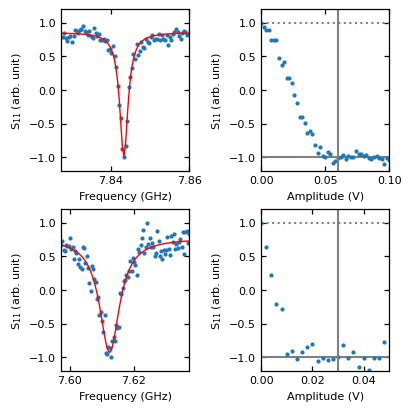

In [ ]:
from cycler import cycler

fig, axes = plt.subplots(2, 2, figsize=(4, 4), constrained_layout=True)

# 共通rcParams
plt.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'font.size': 8,
    'axes.linewidth': 0.9,
    'xtick.top': True,
    'xtick.bottom': True,
    'ytick.left': True,
    'ytick.right': True,
    'lines.linewidth': 1,
    'lines.markersize': 2
})
ge_freq_tx =  8.207+0.000405764-1.388e-05-1.684e-05+4.0565e-05
ge_freq_rx = 7.976+0.001277485-2.569e-05
# -------------------------------
# 1枚目: colormap

ax = axes[0, 0]
PCA1_freq_scaled_tx = scale_y(PCA1_freq_tx, max(PCA1_freq_tx), min(PCA1_freq_tx))
par_ini = {'amp': 2,'const':1,'center':7.842,'k':0.005}
par_min = {'amp': 0,'const':-np.inf,'center':-np.inf,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}
model = lmfit.Model(Lorentzian)
params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result_tx = model.fit(data = -PCA1_freq_scaled_tx, params = params, freq = ge_freq_tx+anhm_tx)

ax.plot(ge_freq_tx+anhm_tx, -PCA1_freq_scaled_tx, "o", c="tab:blue")
ax.plot(ge_freq_tx+anhm_tx, result_tx.best_fit, c="red", lw=1.0)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("S$_{11}$ (arb. unit)")
ax.set_xlim(min(ge_freq_tx+anhm_tx), 7.86)
ax.set_ylim(-1.2, 1.2)

ax = axes[0, 1]
PCA1_amp_scaled_tx = scale_y_with_x(PCA1_amp_tx, amp_tx, 0.05, min(PCA1_amp_tx))
ax.axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax.axhline(y=-1, color="gray", linewidth=1.5)
ax.plot(amp_tx, -PCA1_amp_scaled_tx, "o", c="tab:blue")
ax.set_xlabel("Amplitude (V)")
ax.set_ylabel('S$_{11}$ (arb. unit)')
ax.axvline(x=0.06, color="gray", linewidth=1.5)
ax.set_xlim(0, 0.1)
ax.set_ylim(-1.2, 1.2)
# -------------------------------
# 2枚目: Lorentzian fit 1
ax = axes[1, 0]
PCA1_freq_scaled_rx = scale_y(PCA1_freq_rx, max(PCA1_freq_rx), min(PCA1_freq_rx))
par_ini = {'amp': 2,'const':1,'center':7.618,'k':0.005}
model = lmfit.Model(Lorentzian)
params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result_rx = model.fit(data = PCA1_freq_scaled_rx, params = params, freq = ge_freq_rx+anhm_rx)

ax.plot(ge_freq_rx+anhm_rx, PCA1_freq_scaled_rx, "o", c="tab:blue")
ax.plot(ge_freq_rx+anhm_rx, result_rx.best_fit, c="red", lw=1.0)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("S$_{11}$ (arb. unit)")
ax.set_xlim(min(ge_freq_rx+anhm_rx), max(ge_freq_rx+anhm_rx))
ax.set_ylim(-1.2, 1.2)

ax = axes[1, 1]
PCA1_amp_scaled_rx = scale_y_with_x(PCA1_amp_rx, amp_rx, 0.02, max(PCA1_amp_rx))
ax.axhline(y=1, color="gray", linestyle=":", linewidth=1.5)
ax.axhline(y=-1, color="gray", linewidth=1.5)
ax.plot(amp_rx, -PCA1_amp_scaled_rx, "o", c="tab:blue")
ax.set_xlabel("Amplitude (V)")
ax.set_ylabel('S$_{11}$ (arb. unit)')
ax.axvline(x=0.03, color="gray", linewidth=1.5)
ax.set_xlim(0, 0.05)
ax.set_ylim(-1.2, 1.2)
# -------------------------------
# 表示
# plt.savefig("mas_figs/reset.pdf",  bbox_inches="tight")
plt.show()
